## Amazon Project

---
### Importing Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px
%matplotlib inline

---
### Loading & Inspecting Dataset

In [3]:
df = pd.read_csv('Amazon_smartphones_data.csv')
df.sample(3)

,Unnamed: 0,Description,Name,category,URL,Brand,Rate,number_of_reviews,Discount(%),Price,Storage
7283,7283,"Motorola Edge 60 Moto AI Smartphone, 6.67"" Sup...",Motorola Edge 60 Moto AI Smartphone,Smartphone,https://www.amazon.eg/-/en/Motorola-Smartphone...,Motorola,4.4,60,0.0,"18,499.",12GB
2801,2801,"realme Note70 AI Phone, 128GB Storage, 4GB RAM...",realme Note70 AI Phone,Smartphone,https://www.amazon.eg/-/en/realme-Storage-Smar...,realme,5.0,3,0.0,"6,949.",128GB
4158,4158,"Honor X7d smartphone 8GB RAM, 256GB Storage, 6...",Honor X7d smartphone 8GB RAM,Smartphone,https://www.amazon.eg/-/en/smartphone-Storage-...,Honor,4.4,97,0.0,NaN,8GB


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9439 entries, 0 to 9438
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         9439 non-null   int64  
 1   Description        9259 non-null   str    
 2   Name               9259 non-null   str    
 3   category           9439 non-null   str    
 4   URL                9259 non-null   str    
 5   Brand              9439 non-null   str    
 6   Rate               8899 non-null   float64
 7   number_of_reviews  9439 non-null   int64  
 8   Discount(%)        9439 non-null   float64
 9   Price              8383 non-null   str    
 10  Storage            7745 non-null   str    
dtypes: float64(2), int64(2), str(7)
memory usage: 7.5 MB


In [5]:
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,9439.0,4719.00,2724.95,0.0,2359.5,4719.0,7078.50,9438.00
Rate,8899.0,4.10,0.87,1.0,4.0,4.4,4.50,5.00
number_of_reviews,9439.0,126.38,222.21,0.0,1.0,12.0,128.00,928.00
Discount(%),9439.0,4.27,8.11,0.0,0.0,0.0,7.37,50.83


---
### Data Preprocessing

In [6]:
df.sample(3)

,Unnamed: 0,Description,Name,category,URL,Brand,Rate,number_of_reviews,Discount(%),Price,Storage
7356,7356,"realme Note70 AI Phone, 128GB Storage, 4GB RAM...",realme Note70 AI Phone,Smartphone,https://www.amazon.eg/-/en/realme-Storage-Smar...,realme,5.0,3,0.00,"6,949.",128GB
4239,4239,"Samsung Galaxy A17 LTE, Android Smartphone, 25...",Samsung Galaxy A17 LTE,Smartphone,https://www.amazon.eg/-/en/Samsung-Android-Sma...,Samsung,4.3,238,7.37,"11,505.",256GB
6583,6583,TECHZONE Link Classic Dual SIM Feature Phone |...,TECHZONE Link Classic Dual SIM Feature Phone |...,Smartphone,https://www.amazon.eg/-/en/sspa/click?ie=UTF8&...,TECHZONE,4.5,12,0.00,799.,16GB


In [7]:
# drop first row
df.drop(index= 0  , inplace= True) 

In [8]:
# drop 'Unnamed: 0' Feature
df.drop(columns={'Unnamed: 0'} , inplace= True)


In [9]:
df.drop(columns= {'Storage' } , inplace= True)

In [10]:
df['category'].value_counts() # constant feature

category
Smartphone    9438
Name: count, dtype: int64

In [11]:
df.drop(columns={'category'} , inplace= True)

In [12]:
df['Price'].dtype

<StringDtype(na_value=nan)>

In [13]:
df['Price']

1          270.
2        7,888.
3        9,161.
4        4,799.
5        7,989.
         ...   
9434    26,649.
9435    85,039.
9436    33,119.
9437        90.
9438        59.
Name: Price, Length: 9438, dtype: str

In [14]:
df['Price'] = df['Price'].str.replace(',' , '').str.replace('.' , '')

In [15]:
df['Price']

1         270
2        7888
3        9161
4        4799
5        7989
        ...  
9434    26649
9435    85039
9436    33119
9437       90
9438       59
Name: Price, Length: 9438, dtype: str

In [16]:
df['Price'] = pd.to_numeric(df['Price'])

In [17]:
# Missing Values
df.isna().sum()

Description           179
Name                  179
URL                   179
Brand                   0
Rate                  539
number_of_reviews       0
Discount(%)             0
Price                1055
dtype: int64

In [18]:
df.dropna(subset=['Price'] , inplace= True)

In [19]:
df.dropna(subset=['Description' , 'Name' , 'URL'] , inplace= True)

In [20]:
df['Rate'] = df['Rate'].fillna(0)

In [21]:
df.isna().sum()

Description          0
Name                 0
URL                  0
Brand                0
Rate                 0
number_of_reviews    0
Discount(%)          0
Price                0
dtype: int64

In [22]:
len(df)

8383

In [23]:
# Duplicated Records
df.duplicated().sum()

np.int64(0)

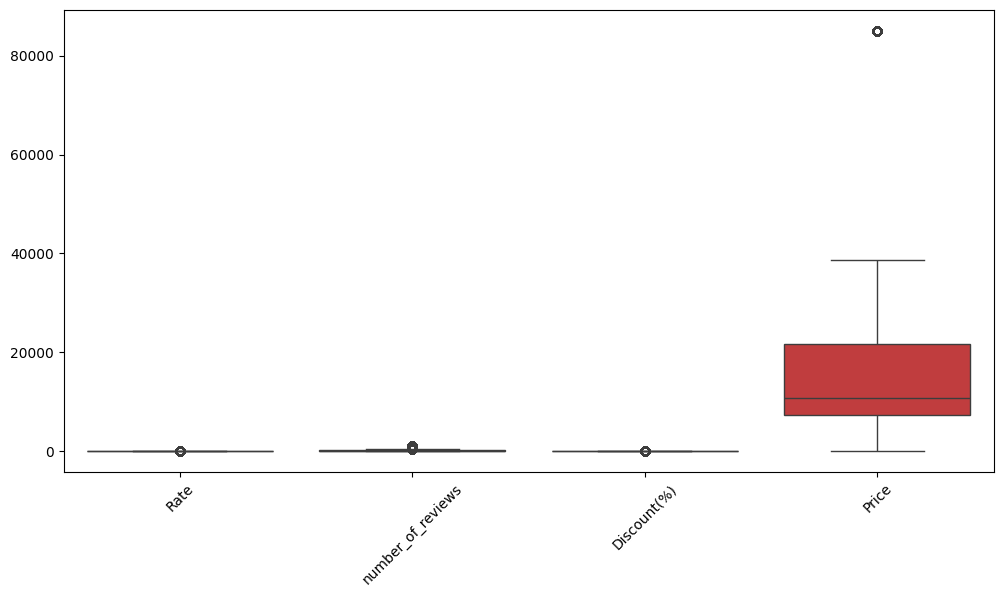

In [24]:
# Outliers
plt.figure(figsize=(12,6))
plt.xticks(rotation = 45)
sns.boxplot(df)
plt.show()

In [25]:
q1 = df['Rate'].quantile(0.25)
q3 = df['Rate'].quantile(0.75)

IQR = q3 - q1

lower_margin = q1 - 1.5 * IQR
upper_margin = q3 + 1.5 * IQR

print(f'len Before remove outliers: {len(df)}')
df = df[(df['Rate'] >= lower_margin) & (df['Rate'] <= upper_margin)]
print(f'len After remove outliers {len(df)}')


len Before remove outliers: 8383
len After remove outliers 7483


In [26]:
q1 = df['number_of_reviews'].quantile(0.25)
q3 = df['number_of_reviews'].quantile(0.75)

IQR = q3 - q1

lower_margin = q1 - 1.5 * IQR
upper_margin = q3 + 1.5 * IQR

print(f'len Before remove outliers: {len(df)}')
df = df[(df['number_of_reviews'] >= lower_margin) & (df['number_of_reviews'] <= upper_margin)]
print(f'len After remove outliers {len(df)}')


len Before remove outliers: 7483
len After remove outliers 6583


In [27]:
q1 = df['Discount(%)'].quantile(0.25)
q3 = df['Discount(%)'].quantile(0.75)

IQR = q3 - q1

lower_margin = q1 - 1.5 * IQR
upper_margin = q3 + 1.5 * IQR

print(f'len Before remove outliers: {len(df)}')
df = df[(df['Discount(%)'] >= lower_margin) & (df['Discount(%)'] <= upper_margin)]
print(f'len After remove outliers {len(df)}')


len Before remove outliers: 6583
len After remove outliers 6403


In [28]:
q1 = df['Price'].quantile(0.25)
q3 = df['Price'].quantile(0.75)

IQR = q3 - q1

lower_margin = q1 - 1.5 * IQR
upper_margin = q3 + 1.5 * IQR

print(f'len Before remove outliers: {len(df)}')
df = df[(df['Price'] >= lower_margin) & (df['Price'] <= upper_margin)]
print(f'len After remove outliers {len(df)}')


len Before remove outliers: 6403
len After remove outliers 6223


In [29]:
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
Rate,6223.0,4.24,0.56,2.8,4.0,4.3,4.60,5.00
number_of_reviews,6223.0,60.41,88.17,0.0,5.0,11.0,73.00,330.00
Discount(%),6223.0,2.76,4.20,0.0,0.0,0.0,7.37,13.21
Price,6223.0,13881.31,10524.44,90.0,7249.0,9499.0,21687.00,38720.00


In [30]:
df['Price'].min() # Not Smartphones!!

np.float64(90.0)

In [31]:
df = df[df['Price'] >= 700]

In [32]:
df['Brand'].value_counts()

Brand
Samsung     1260
Infinix     1080
realme       730
Motorola     540
XIAOMI       360
HONOR        360
Tecno        360
Nothing      360
Xiaomi       180
TECHZONE     180
OPPO         180
HUAWEI       180
Nokia         29
ITEL          24
Name: count, dtype: int64

In [33]:
# XIAOMI = 360 !!!
# Xiaomi = 180 !!!

df['Brand'] = df['Brand'].str.title()

In [34]:
df['Brand'].value_counts()

Brand
Samsung     1260
Infinix     1080
Realme       730
Xiaomi       540
Motorola     540
Honor        360
Tecno        360
Nothing      360
Techzone     180
Oppo         180
Huawei       180
Nokia         29
Itel          24
Name: count, dtype: int64

In [35]:
# Create price segments
def price_category(price):
    if price < 5000:
        return 'Budget (<5K EGP)'
    elif price < 15000:
        return 'Mid-Range (5K-15K EGP)'
    elif price < 30000:
        return 'Premium (15K-30K EGP)'
    else:
        return 'Flagship (30K+ EGP)'

df['Price_Category'] = df['Price'].apply(price_category)

In [36]:
# Create rating categories
def rating_category(rating):
    if rating >= 4.5:
        return 'Excellent (4.5-5.0)'
    elif rating >= 4.0:
        return 'Good (4.0-4.4)'
    elif rating >= 3.0:
        return 'Average (3.0-3.9)'
    else:
        return 'Poor (<3.0)'

df['Rating_Category'] = df['Rate'].apply(rating_category)

In [37]:
df.reset_index(drop= True,inplace= True)

---
### Save Dataset

In [38]:
df.to_csv('Amazon_smartphones_cleaned_data.csv', index= False)

---
### EDA
- **Uni-Variant Analysis**
- **Bi-Variant Analysis**
- **Multi-Variant Analysis**


#### **Brand**
- **Uni-Varaiant Analysis**

In [39]:
# Brand Overview
df['Brand'].describe(include='O')

count        5823
unique         13
top       Samsung
freq         1260
Name: Brand, dtype: object

In [40]:
df['Brand'].value_counts().sort_values(ascending= False)

Brand
Samsung     1260
Infinix     1080
Realme       730
Xiaomi       540
Motorola     540
Honor        360
Tecno        360
Nothing      360
Techzone     180
Oppo         180
Huawei       180
Nokia         29
Itel          24
Name: count, dtype: int64

In [41]:
round(df['Brand'].value_counts() / len(df),3) * 100

Brand
Samsung     21.6
Infinix     18.5
Realme      12.5
Xiaomi       9.3
Motorola     9.3
Honor        6.2
Tecno        6.2
Nothing      6.2
Techzone     3.1
Oppo         3.1
Huawei       3.1
Nokia        0.5
Itel         0.4
Name: count, dtype: float64

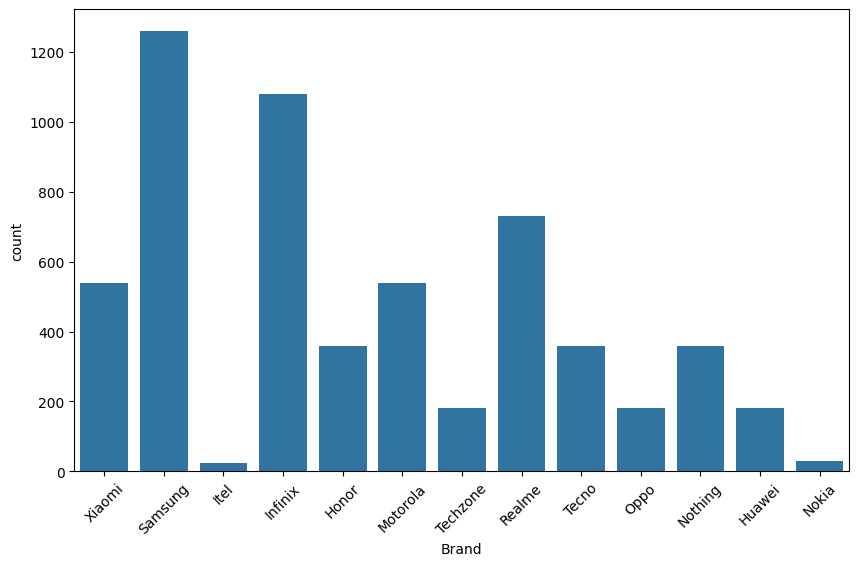

In [42]:
plt.figure(figsize=(10,6))
plt.xticks(rotation = 45)
sns.countplot(data= df,
              x= 'Brand'
              )

plt.show()

### **Brand**
- **Bi-Varaiant Analysis**

In [43]:
df.sample(2)

,Description,Name,URL,Brand,Rate,number_of_reviews,Discount(%),Price,Price_Category,Rating_Category
3387,"realme 15T 5G AI Phone, 256GB Storage, 12GB RA...",realme 15T 5G AI Phone,https://www.amazon.eg/-/en/realme-Titanium-Sma...,Realme,4.0,1,9.35,16949.0,Premium (15K-30K EGP),Good (4.0-4.4)
714,"OPPO Reno15 Pro 5G 12GB 512GB Aurora Blue, Unl...",OPPO Reno15 Pro 5G 12GB 512GB Aurora Blue,https://www.amazon.eg/-/en/OPPO-Unlocked-Dimen...,Oppo,5.0,1,7.70,38720.0,Flagship (30K+ EGP),Excellent (4.5-5.0)


#### What are the total number of reviews for each Brand?

In [44]:
df.groupby('Brand')['number_of_reviews'].sum().sort_values(ascending= False)

Brand
Samsung     169740
Infinix      83880
Xiaomi       32940
Honor        23760
Motorola     20880
Nothing      10260
Realme        3585
Tecno         2520
Huawei        2160
Techzone      2160
Oppo           180
Itel            24
Nokia            0
Name: number_of_reviews, dtype: int64

#### Which brands get the most reviews (most popular with buyers)?

In [45]:
df.groupby('Brand')['number_of_reviews'].mean().round(2).sort_values(ascending= False).head()

Brand
Samsung     134.71
Infinix      77.67
Honor        66.00
Xiaomi       61.00
Motorola     38.67
Name: number_of_reviews, dtype: float64

####  Which brands are most expensive?

In [46]:
df.groupby('Brand')['Price'].mean().round(2).sort_values(ascending= False).head(5)

Brand
Oppo        38720.00
Huawei      33119.00
Nothing     29499.00
Motorola    18874.33
Samsung     18370.57
Name: Price, dtype: float64

#### Which brands are most cheaper?

In [47]:
df.groupby('Brand')['Price'].mean().round(2).sort_values(ascending= False).tail(5)


Brand
Infinix     8868.0
Tecno       5399.0
Itel        4799.0
Techzone     799.0
Nokia        719.0
Name: Price, dtype: float64

#### Wich brands have the highest average ratings?

In [48]:
df.groupby('Brand')['Rate'].mean().round(2).sort_values(ascending=False).head()

Brand
Itel        5.00
Oppo        5.00
Honor       4.75
Techzone    4.50
Nothing     4.45
Name: Rate, dtype: float64

#### Which brands offer the best discounts?

In [49]:
df.groupby('Brand')['Discount(%)'].mean().round(2).sort_values(ascending= False).head()

Brand
Samsung     8.50
Oppo        7.70
Motorola    4.40
Honor       2.92
Realme      2.31
Name: Discount(%), dtype: float64

#### Price vs Rating Correlation by Brand

In [50]:
df.groupby('Brand').agg(
    AVG_Price = ('Price' , 'mean'),
    AVG_Rate = ('Rate' , 'mean'),
    Sum_num_of_reviews = ('number_of_reviews' , 'sum')
).round(2).head(10)

,AVG_Price,AVG_Rate,Sum_num_of_reviews
Brand,,,
Honor,14176.50,4.75,23760
Huawei,33119.00,4.20,2160
Infinix,8868.00,4.43,83880
Itel,4799.00,5.00,24
Motorola,18874.33,4.43,20880
Nokia,719.00,3.20,0
Nothing,29499.00,4.45,10260
Oppo,38720.00,5.00,180
Realme,10073.36,4.02,3585


In [51]:
df.head(2)

,Description,Name,URL,Brand,Rate,number_of_reviews,Discount(%),Price,Price_Category,Rating_Category
0,"XIAOMI Poco C85, Smartphone 8+256GB, 6.9"" 120H...",XIAOMI Poco C85,https://www.amazon.eg/-/en/C85-Smartphone-Medi...,Xiaomi,4.5,0,0.00,7888.0,Mid-Range (5K-15K EGP),Excellent (4.5-5.0)
1,"Samsung Galaxy A17 LTE, Android Smartphone, 12...",Samsung Galaxy A17 LTE,https://www.amazon.eg/-/en/Samsung-Android-Sma...,Samsung,4.3,238,9.74,9161.0,Mid-Range (5K-15K EGP),Good (4.0-4.4)


### **Price**
- **Bi-Varaiant Analysis**

In [52]:
df['Price'].describe().round(2).T

count     5823.00
mean     14825.59
std      10222.49
min        719.00
25%       7299.00
50%      10599.00
75%      21687.00
max      38720.00
Name: Price, dtype: float64

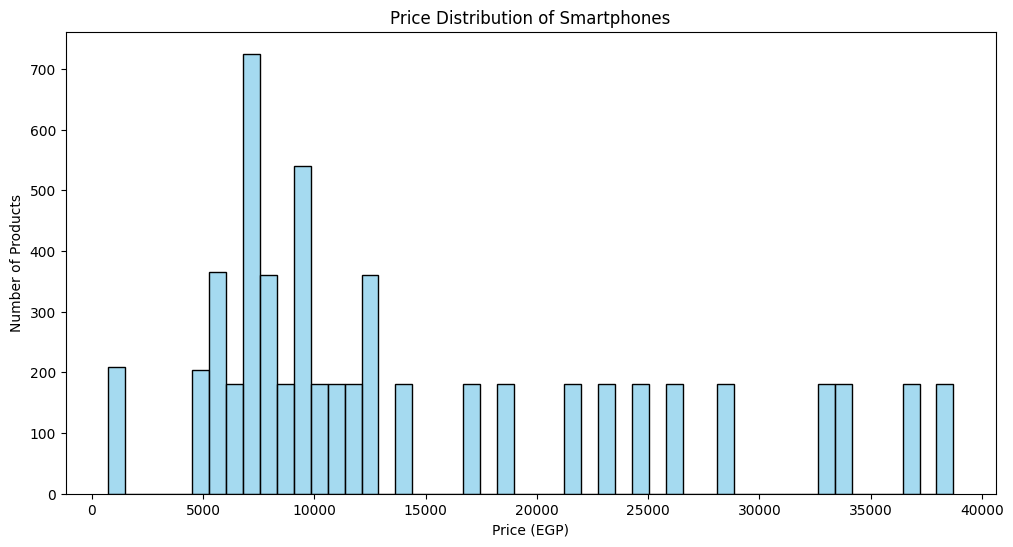

In [53]:
plt.figure(figsize=(12, 6))
sns.histplot(df['Price'] , bins= 50 , edgecolor= 'black' , color= 'skyblue')
plt.title('Price Distribution of Smartphones')
plt.xlabel('Price (EGP)')
plt.ylabel('Number of Products')
plt.show()

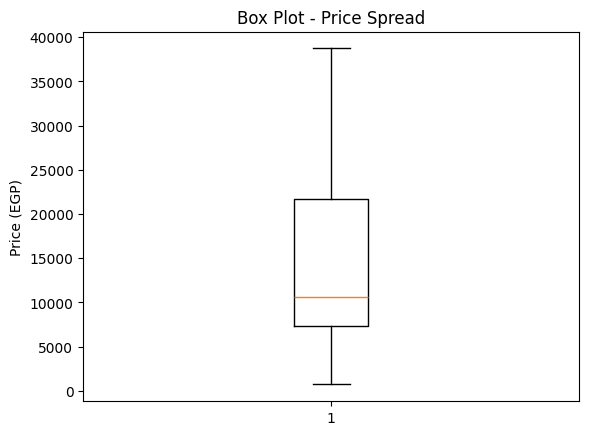

In [54]:
plt.boxplot(df['Price'])
plt.title('Box Plot - Price Spread')
plt.ylabel('Price (EGP)')
plt.show()

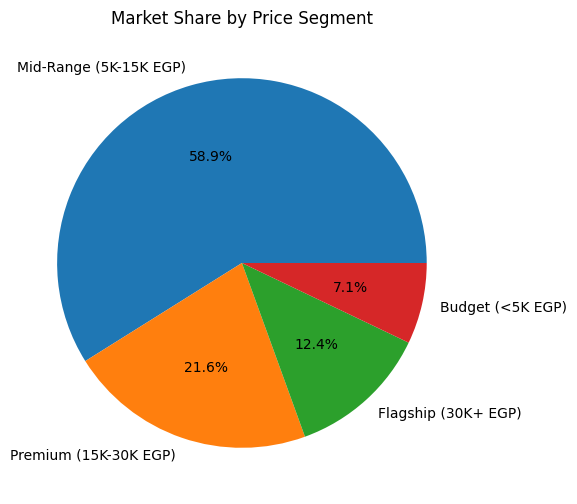

In [55]:
plt.figure(figsize=(8, 6))
category_counts = df['Price_Category'].value_counts()
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%')
plt.title('Market Share by Price Segment')
plt.show()

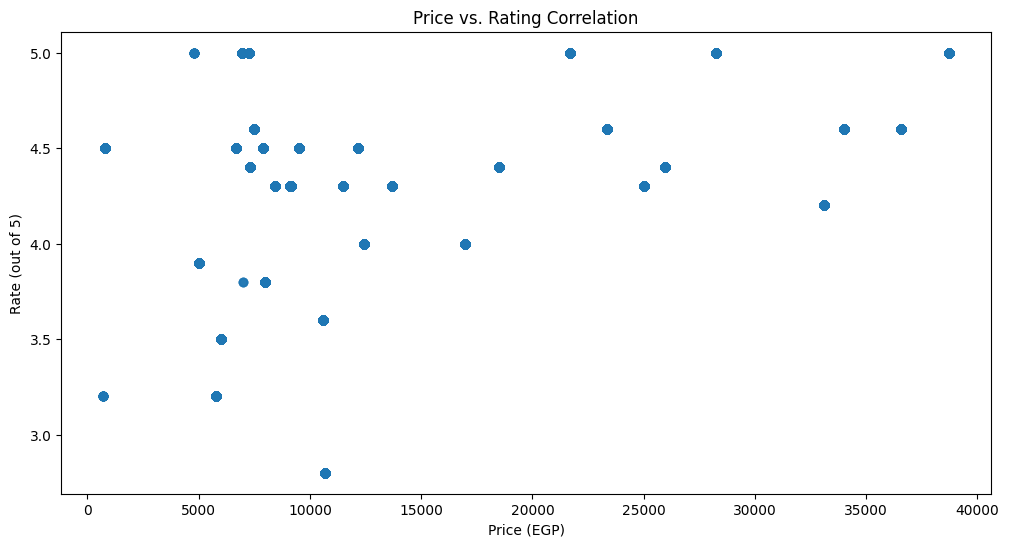

In [56]:
# Price vs. Rating Correlation

plt.figure(figsize=(12,6))
plt.scatter(df['Price'] , df['Rate'], alpha= 0.5)
plt.xlabel('Price (EGP)')
plt.ylabel('Rate (out of 5)')
plt.title('Price vs. Rating Correlation')
plt.show()

In [57]:
# Correlation coefficient
correlation = df['Price'].corr(df['Rate'])
print(f"Correlation between Price and Rating: {correlation:.3f}")

Correlation between Price and Rating: 0.352


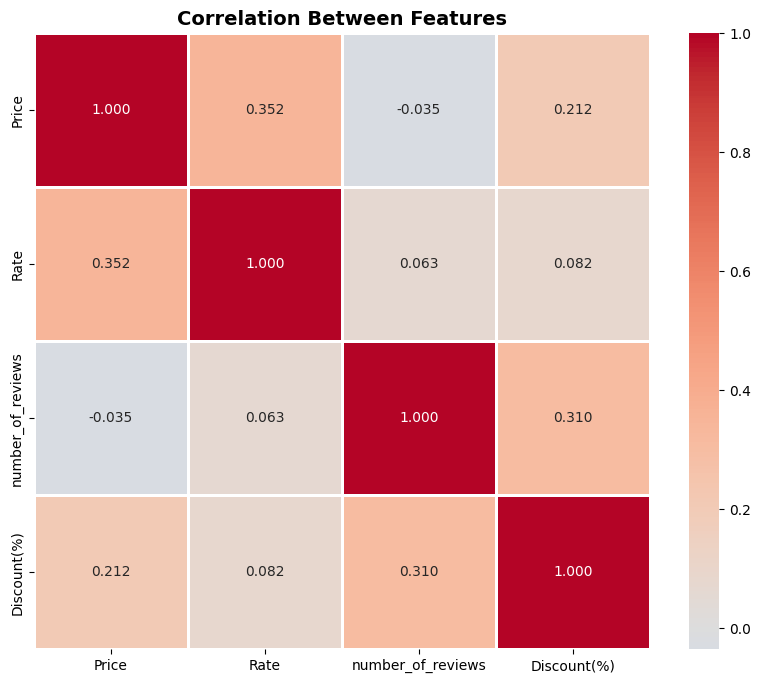

In [58]:
# Correlation matrix
correlation_matrix = df[['Price', 'Rate', 'number_of_reviews', 'Discount(%)']].corr()

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.3f', square=True, linewidths=1)
plt.title('Correlation Between Features', fontsize=14, fontweight='bold')
plt.show()


In [59]:
df.groupby('Price_Category').agg({
    'Rate': ['mean', 'median', 'count'],
    'number_of_reviews': 'mean'
}).round(2)


Rate              number_of_reviews
                        mean median count              mean
Price_Category                                             
Budget (<5K EGP)        4.18    3.9   413              9.65
Flagship (30K+ EGP)     4.60    4.6   720             65.50
Mid-Range (5K-15K EGP)  4.18    4.3  3430             82.28
Premium (15K-30K EGP)   4.53    4.4  1260             14.86